In [50]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')


In [51]:
## importing the dataset
df = pd.read_csv('data/Churn_Modelling.csv')

In [52]:
df.head() 

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [53]:
df.shape ## (10000, 14)

(10000, 14)

In [54]:
## The dataset has 10,000 rows and 14 columns.
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [55]:
df.isnull().sum() ## There are no missing values in the dataset.

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [56]:
df.describe() ## The dataset has a wide range of values for the numerical variables, which may require scaling before training the model.

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [57]:
## Preprocess the data
df = df.drop(["RowNumber","CustomerId","Surname",], axis=1) # droping coulmn from the feature 

In [58]:
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [59]:
## Feature Scaling and Encoding

## The dataset contains both numerical and categorical variables. We need to encode the categorical variables before we can use them in our machine learning model.
from sklearn.preprocessing import LabelEncoder
import pickle ## Pickle is commonly used to save machine learning models after training, so that they can be loaded and used later without having to retrain the model.



le_gender =LabelEncoder() ## Encode categorical variables
df['Gender']= le_gender.fit_transform(df['Gender']) ## This would change the Columns to Zeros(0) and Ones(1)
df.head(5)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,0,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,0,41,1,83807.86,1,0,1,112542.58,0
2,502,France,0,42,8,159660.80,3,1,0,113931.57,1
3,699,France,0,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,0,43,2,125510.82,1,1,1,79084.10,0


In [60]:
## One-hot encode the 'Geography' column
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder()
geo_encoded = encoder.fit_transform(df[['Geography']])
geo_encoded


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 10000 stored elements and shape (10000, 3)>

In [61]:
geo_encoded.toarray() ## Convert the sparse matrix to a dense array

array([[1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       ...,
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.]])

In [62]:
encoder.get_feature_names_out(['Geography'])



array(['Geography_France', 'Geography_Germany', 'Geography_Spain'],
      dtype=object)

In [63]:
geo_encoded_df = pd.DataFrame(geo_encoded.toarray(), columns=encoder.get_feature_names_out(['Geography']))
geo_encoded_df.head()

,Geography_France,Geography_Germany,Geography_Spain
0,1.0,0.0,0.0
1,0.0,0.0,1.0
2,1.0,0.0,0.0
3,1.0,0.0,0.0
4,0.0,0.0,1.0


In [64]:
## combine the original dataframe with the one-hot encoded dataframe
df = pd.concat([df.drop('Geography', axis=1), geo_encoded_df], axis=1)
df.head() ## The 'Geography' column has been replaced with three new columns: 'Geography_France', 'Geography_Germany', and 'Geography_Spain', which indicate the presence of each category in the original 'Geography' column.

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,1.0,0.0,0.0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0.0,0.0,1.0
2,502,0,42,8,159660.80,3,1,0,113931.57,1,1.0,0.0,0.0
3,699,0,39,1,0.00,2,0,0,93826.63,0,1.0,0.0,0.0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0.0,0.0,1.0


## Splitting data for testing 

In [67]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
## Divide the data to indepent and dependent variable, X--> independent variable and y--> dependent variable
X = df.drop('Exited', axis=1) # Features
y = df['Exited'] # Target variable

## Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [68]:

## standard scaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [69]:
X_train.shape, X_test.shape

((8000, 12), (2000, 12))

## Building the ANN model

In [70]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping,TensorBoard
import datetime

In [71]:
ann =tf.keras.models.Sequential()

In [72]:
ann.add(tf.keras.layers.Dense(units=6, activation='relu')) ## First hidden layer with 64 neurons and ReLU activation function, and input shape equal to the number of features in the training data
ann.add(tf.keras.layers.Dense(units=6, activation='relu')) ## Second hidden layer with 32 neurons and ReLU activation function
ann.add(tf.keras.layers.Dense(units=1, activation='sigmoid')) ## Output layer


In [73]:
ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy']) ## Compile the model with Adam optimizer, binary cross-entropy loss function, and accuracy as a metric

In [74]:
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
ann_m = ann.fit(X_train, y_train, validation_data=(X_test, y_test), batch_size=32, epochs=100, callbacks=[early_stopping]) ## Train the model with a batch size of 32 and a maximum of 100 epochs

Epoch 1/100
250/250 [==============================] - 1s 4ms/step - loss: 0.5831 - accuracy: 0.7021 - val_loss: 0.4964 - val_accuracy: 0.7885
Epoch 2/100
250/250 [==============================] - 1s 3ms/step - loss: 0.4638 - accuracy: 0.8043 - val_loss: 0.4538 - val_accuracy: 0.8120
Epoch 3/100
250/250 [==============================] - 1s 3ms/step - loss: 0.4439 - accuracy: 0.8100 - val_loss: 0.4446 - val_accuracy: 0.8175
Epoch 4/100
250/250 [==============================] - 1s 3ms/step - loss: 0.4407 - accuracy: 0.8120 - val_loss: 0.4418 - val_accuracy: 0.8155
Epoch 5/100
250/250 [==============================] - 1s 3ms/step - loss: 0.4390 - accuracy: 0.8149 - val_loss: 0.4444 - val_accuracy: 0.8225
Epoch 6/100
250/250 [==============================] - 1s 3ms/step - loss: 0.4395 - accuracy: 0.8121 - val_loss: 0.4437 - val_accuracy: 0.8245
Epoch 7/100
250/250 [==============================] - 1s 3ms/step - loss: 0.4387 - accuracy: 0.8119 - val_loss: 0.4430 - val_accuracy: 0.8220

In [75]:
best_epoch = np.argmin(ann_m.history['val_loss']) + 1
print("Best epoch:", best_epoch)


Best epoch: 18


In [76]:
best_val_loss = np.min(ann_m.history['val_loss'])

print("Best epoch:", best_epoch)
print("Best validation loss:", best_val_loss)

Best epoch: 18
Best validation loss: 0.43066126108169556


In [77]:
best_val_acc_epoch = np.argmax(ann_m.history['val_accuracy']) + 1
best_val_acc = np.max(ann_m.history['val_accuracy'])

print("Best accuracy epoch:", best_val_acc_epoch)
print("Best validation accuracy:", best_val_acc)

Best accuracy epoch: 6
Best validation accuracy: 0.8245000243186951


In [78]:
import matplotlib.pyplot as plt

In [79]:
# plt.figure(figsize=(8,5))

# plt.plot(ann_m.history['val_loss'], label='Validation Loss')

# plt.axvline(best_epoch-1, color='red', linestyle='--', label='Best Epoch')

# plt.title("Validation Loss with Best Epoch")
# plt.legend()
# plt.show()

In [80]:
print(ann.predict(scaler.transform([[1, 0, 0, 600, 1, 30, 3, 60000, 2, 1, 1, 50000]]))) ## Predict the output for a single input sample

1/1 [==============================] - 0s 21ms/step
[[0.]]


In [81]:
print(ann_m.history.keys())

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


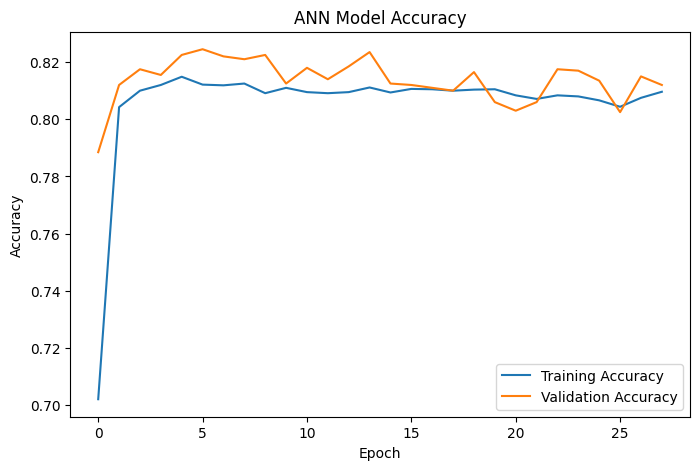

In [82]:

plt.figure(figsize=(8,5))

plt.plot(ann_m.history['accuracy'], label='Training Accuracy')
plt.plot(ann_m.history['val_accuracy'], label='Validation Accuracy')

plt.title('ANN Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

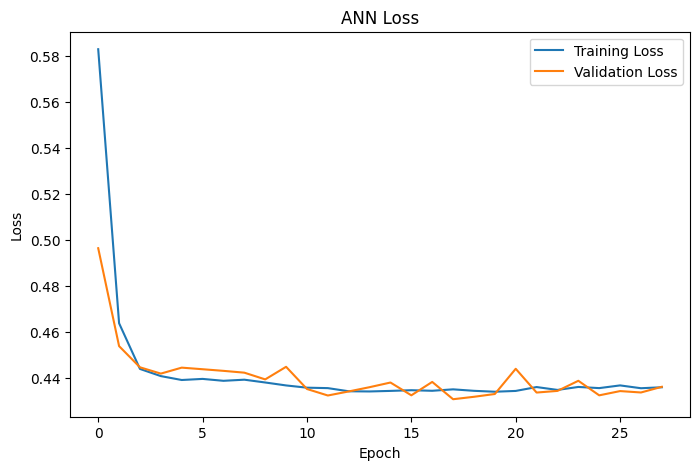

In [83]:
plt.figure(figsize=(8,5))

plt.plot(ann_m.history['loss'], label='Training Loss')
plt.plot(ann_m.history['val_loss'], label='Validation Loss')

plt.title('ANN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

63/63 [==============================] - 0s 984us/step


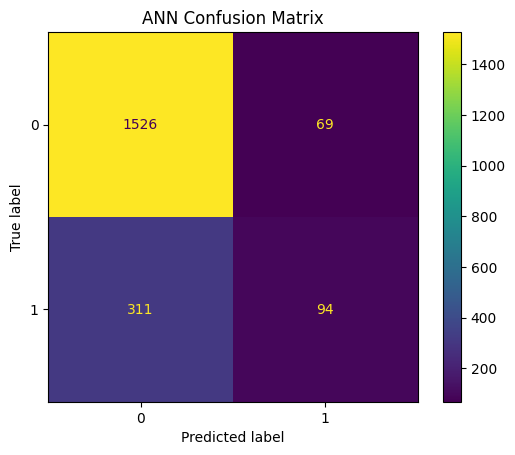

In [84]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_prob = ann.predict(X_test)
y_pred = (y_prob > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()
plt.title("ANN Confusion Matrix")
plt.show()

In [85]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
print('accuracy_score:', accuracy_score(y_test, y_pred))
print('precision_score:', precision_score(y_test, y_pred))
print('recall_score:', recall_score(y_test, y_pred))
print('f1_score:', f1_score(y_test, y_pred))
print('roc_auc_score:', roc_auc_score(y_test, y_pred))  

accuracy_score: 0.81
precision_score: 0.5766871165644172
recall_score: 0.23209876543209876
f1_score: 0.33098591549295775
roc_auc_score: 0.5944192886721622
